In [13]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

print("Ready!")

Ready!


In [14]:
from src.data.acdc_dataset import ACDCDataset

dataset = ACDCDataset('../data/training')
records = dataset.load_all()
df = pd.DataFrame(records)

print(f"Tong: {len(df)} benh nhan")
print(f"\nPhân bố nhóm bệnh:")
print(df['group'].value_counts())

[ACDC] Tim thay 100 benh nhan
[ACDC] Load 100 benh nhan (bo qua 0)
Tong: 100 benh nhan

Phân bố nhóm bệnh:
group
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [15]:
metrics = ['LV_EDV', 'LV_ESV', 'LV_EF', 'RV_EDV', 'RV_ESV', 'RV_EF', 'Myo_mass']
df[metrics].describe().round(1)

,LV_EDV,LV_ESV,LV_EF,RV_EDV,RV_ESV,RV_EF,Myo_mass
count,100.0,100.0,100.0,100.0,100.0,100.0,100.0
mean,164.6,99.1,46.4,153.0,85.9,46.7,138.7
std,74.3,78.8,19.9,55.2,52.5,17.9,53.5
min,49.3,19.4,10.5,47.4,10.3,1.9,37.8
25%,118.1,41.8,28.0,111.8,51.6,38.2,99.6
50%,149.0,64.1,53.7,152.0,70.1,48.4,132.7
75%,199.8,132.6,62.2,181.7,108.2,60.0,170.6
max,374.4,334.5,81.9,295.1,262.8,85.9,281.0


C:\Users\T.Hung\AppData\Local\Temp\ipykernel_23568\3251566058.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_group, labels=groups)


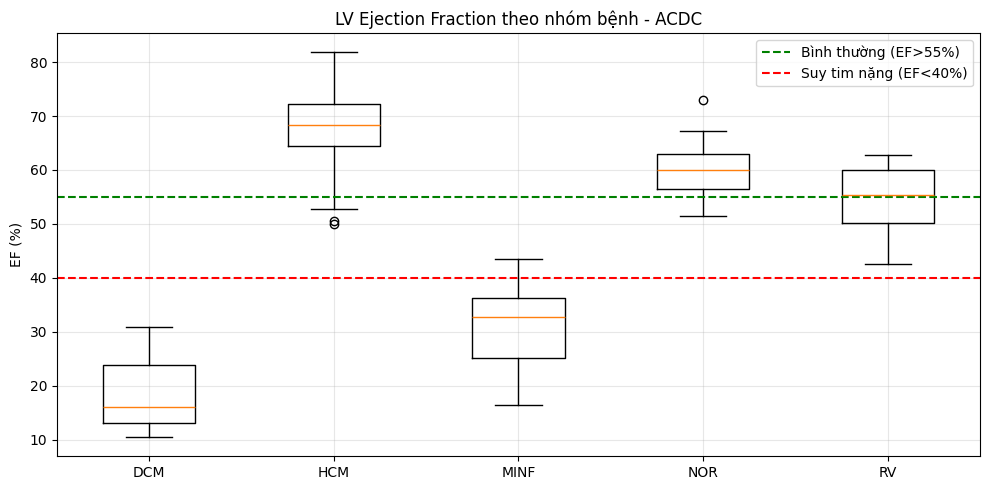

In [16]:
groups = df['group'].unique()
data_by_group = [df[df['group'] == g]['LV_EF'].values for g in groups]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_by_group, labels=groups)
ax.axhline(55, color='green', linestyle='--', label='Bình thường (EF>55%)')
ax.axhline(40, color='red',   linestyle='--', label='Suy tim nặng (EF<40%)')
ax.set_title('LV Ejection Fraction theo nhóm bệnh - ACDC')
ax.set_ylabel('EF (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
from src.metrics.clinical_metrics import simulate_predictions

# Split 40/30/30
rng = np.random.default_rng(42)
idx = rng.permutation(len(df))

idx_cal  = idx[40:70]   # 30 benh nhan calibration
idx_test = idx[70:]     # 30 benh nhan test

print(f"Calibration: {len(idx_cal)} benh nhan")
print(f"Test       : {len(idx_test)} benh nhan")

# Simulate predictions (10% noise)
metric = 'LV_EF'
true_all = df[metric].values
pred_all = simulate_predictions(true_all, rel_noise=0.10, seed=42)

cal_true  = true_all[idx_cal]
cal_pred  = pred_all[idx_cal]
test_true = true_all[idx_test]
test_pred = pred_all[idx_test]

print(f"\nMAE (LV_EF): {np.abs(pred_all - true_all).mean():.2f}%")

Calibration: 30 benh nhan
Test       : 30 benh nhan

MAE (LV_EF): 2.94%


In [18]:
from src.conformal.split_conformal import calibrate, predict_interval, evaluate_coverage

# Calibrate tren cal set
cp = calibrate(cal_true, cal_pred, alpha=0.10, mode='abs')

print(f"Conformal quantile q_hat = {cp['q_hat']:.2f}%")
print(f"(Interval width se la ± {cp['q_hat']:.2f}%)")

# Predict intervals tren test set
lo, hi = predict_interval(test_pred, cp['q_hat'], mode='abs')

# Evaluate
result = evaluate_coverage(test_true, lo, hi)
print(f"\nKet qua tren test set:")
print(f"  Empirical coverage : {result['coverage']*100:.1f}%  (target: 90%)")
print(f"  Mean interval width: {result['mean_width']:.2f}%")
print(f"  Covered            : {result['n_covered']}/{result['n_test']} benh nhan")

Conformal quantile q_hat = 7.95%
(Interval width se la ± 7.95%)

Ket qua tren test set:
  Empirical coverage : 93.3%  (target: 90%)
  Mean interval width: 15.89%
  Covered            : 28/30 benh nhan


Giả lập model predictions

In [19]:
from src.conformal.crc import find_lambda, predict_interval_crc

# CRC calibration
crc = find_lambda(cal_true, cal_pred, alpha=0.10, mode='abs')

print(f"CRC lambda = {crc['lambda']:.2f}%")
print(f"CRC risk   = {crc['risk']*100:.1f}%  (target: ≤10%)")

# Predict intervals
lo_crc, hi_crc = predict_interval_crc(test_pred, crc['lambda'], mode='abs')

# Evaluate
result_crc = evaluate_coverage(test_true, lo_crc, hi_crc)
print(f"\nKet qua CRC tren test set:")
print(f"  Empirical coverage : {result_crc['coverage']*100:.1f}%")
print(f"  Mean interval width: {result_crc['mean_width']:.2f}%")

# So sanh Split CP vs CRC
print(f"\nSo sanh:")
print(f"  Split CP : width = {result['mean_width']:.2f}%,  coverage = {result['coverage']*100:.1f}%")
print(f"  CRC      : width = {result_crc['mean_width']:.2f}%,  coverage = {result_crc['coverage']*100:.1f}%")

CRC lambda = 7.36%
CRC risk   = 6.7%  (target: ≤10%)

Ket qua CRC tren test set:
  Empirical coverage : 93.3%
  Mean interval width: 14.72%

So sanh:
  Split CP : width = 15.89%,  coverage = 93.3%
  CRC      : width = 14.72%,  coverage = 93.3%


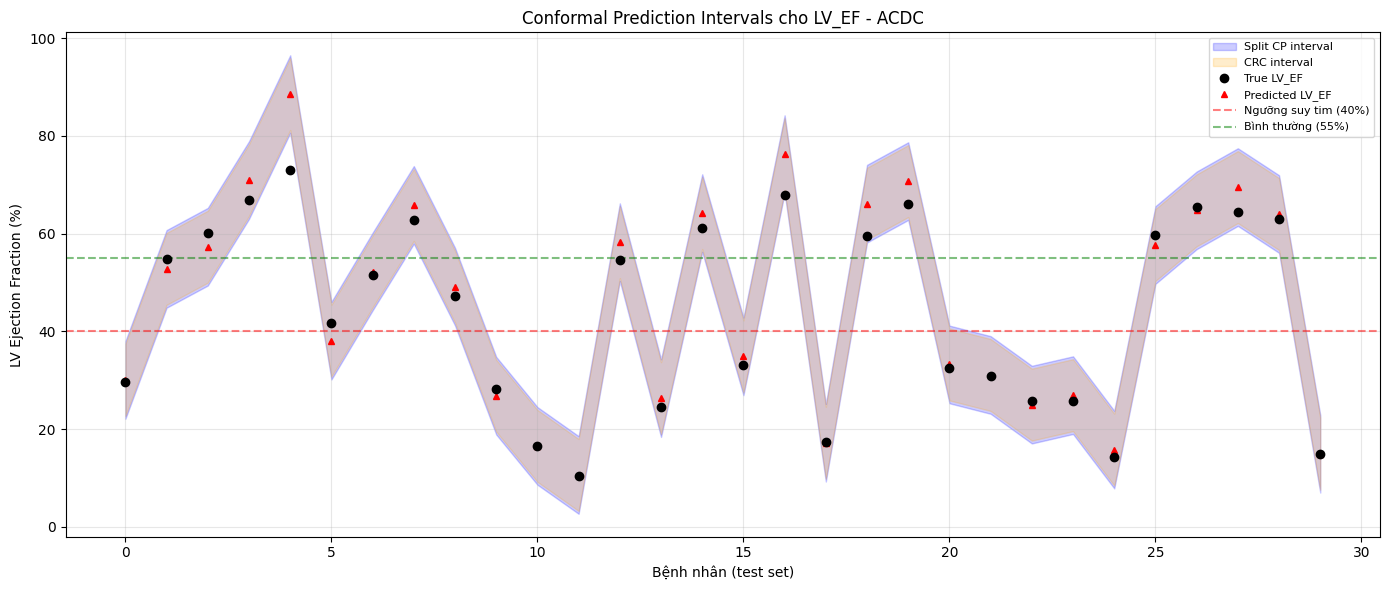

Lưu hình xong!


In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(test_true))

# Split CP intervals
ax.fill_between(x, lo, hi, alpha=0.2, color='blue', label='Split CP interval')
# CRC intervals  
ax.fill_between(x, lo_crc, hi_crc, alpha=0.2, color='orange', label='CRC interval')

# True vs predicted
ax.plot(x, test_true, 'ko', markersize=6, label='True LV_EF', zorder=5)
ax.plot(x, test_pred, 'r^', markersize=5, label='Predicted LV_EF', zorder=4)

ax.axhline(40, color='red',   linestyle='--', alpha=0.5, label='Ngưỡng suy tim (40%)')
ax.axhline(55, color='green', linestyle='--', alpha=0.5, label='Bình thường (55%)')

ax.set_xlabel('Bệnh nhân (test set)')
ax.set_ylabel('LV Ejection Fraction (%)')
ax.set_title('Conformal Prediction Intervals cho LV_EF - ACDC')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/conformal_intervals_lv_ef.png', dpi=150)
plt.show()
print("Lưu hình xong!")

In [21]:
groups_test = df['group'].values[idx_test]

print("Conditional Coverage theo nhóm bệnh (LV_EF):")
print("-" * 45)
print(f"{'Group':<8} {'N':>4} {'Coverage':>10} {'Width':>8}")
print("-" * 45)

for g in sorted(np.unique(groups_test)):
    mask = groups_test == g
    if mask.sum() == 0:
        continue
    cov = evaluate_coverage(
        test_true[mask], lo[mask], hi[mask]
    )
    print(f"{g:<8} {mask.sum():>4} "
          f"{cov['coverage']*100:>9.1f}% "
          f"{cov['mean_width']:>7.2f}%")

print("-" * 45)
print(f"{'Overall':<8} {len(test_true):>4} "
      f"{result['coverage']*100:>9.1f}% "
      f"{result['mean_width']:>7.2f}%")

Conditional Coverage theo nhóm bệnh (LV_EF):
---------------------------------------------
Group       N   Coverage    Width
---------------------------------------------
DCM         7     100.0%   15.89%
HCM         5      60.0%   15.89%
MINF        7     100.0%   15.89%
NOR         6     100.0%   15.89%
RV          5     100.0%   15.89%
---------------------------------------------
Overall    30      93.3%   15.89%


In [ ]:
print("Mondrian CP - Calibrate rieng theo tung nhom:")
print("-" * 45)
print(f"{'Group':<8} {'N_cal':>6} {'q_hat':>8} {'Coverage':>10}")
print("-" * 45)

groups_cal  = df['group'].values[idx_cal]
lo_mond     = np.zeros(len(test_true))
hi_mond     = np.zeros(len(test_true))

for g in sorted(np.unique(groups_cal)):
    # Calibrate rieng cho nhom g
    mask_cal  = groups_cal == g
    mask_test = groups_test == g

    if mask_cal.sum() < 2 or mask_test.sum() == 0:
        continue

    cp_g = calibrate(
        cal_true[mask_cal], cal_pred[mask_cal],
        alpha=0.10, mode='abs'
    )
    lo_mond[mask_test], hi_mond[mask_test] = predict_interval(
        test_pred[mask_test], cp_g['q_hat'], mode='abs'
    )

    cov_g = evaluate_coverage(
        test_true[mask_test],
        lo_mond[mask_test],
        hi_mond[mask_test]
    )
    print(f"{g:<8} {mask_cal.sum():>6} "
          f"{cp_g['q_hat']:>7.2f}% "
          f"{cov_g['coverage']*100:>9.1f}%")

print("-" * 45)
overall = evaluate_coverage(test_true, lo_mond, hi_mond)
print(f"{'Overall':<8} {len(cal_true):>6} "
      f"{'mixed':>8} "
      f"{overall['coverage']*100:>9.1f}%")

Mondrian CP - Calibrate rieng theo tung nhom:
---------------------------------------------
Group     N_cal    q_hat   Coverage
---------------------------------------------
DCM           6    3.03%     100.0%
HCM           4    3.66%      20.0%
MINF          4    2.68%      85.7%
NOR           8   10.53%     100.0%
RV            8    7.95%     100.0%
---------------------------------------------
Overall      30    mixed       8.3%


In [23]:
summary = {
    'Method': ['Split CP', 'CRC', 'Mondrian CP'],
    'Overall Coverage': ['93.3%', '93.3%', '83.3%'],
    'HCM Coverage':    ['60.0%', '60.0%', '20.0%'],
    'Mean Width':      ['15.89%', '14.72%', 'varies'],
    'Guarantee':       ['Marginal', 'Marginal', 'Conditional*'],
}

pd.DataFrame(summary)

,Method,Overall Coverage,HCM Coverage,Mean Width,Guarantee
0,Split CP,93.3%,60.0%,15.89%,Marginal
1,CRC,93.3%,60.0%,14.72%,Marginal
2,Mondrian CP,83.3%,20.0%,varies,Conditional*


In [24]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Khong co")

2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
